# FloodNet Track 1 — U-Net híbrido CNN + ViT con Attention Gates

Segmentación semántica de imágenes aéreas de inundaciones: clasificar **cada píxel**
de una foto de dron en una de 10 clases.

Este cuaderno es **autocontenido**. Incluye el montaje del entorno, la preparación
de los datos, el modelo, el entrenamiento y la evaluación. No hace falta ningún
script externo.

---

## Índice

| Sección | Contenido |
|---|---|
| **0** | Entorno reproducible con `uv` |
| **1** | Los datos: qué hay, qué falta y qué está roto |
| **2** | EDA — distribución de clases |
| **3** | Preprocesado: oversampling y augmentación |
| **4** | Arquitectura del modelo |
| **5** | Entrenamiento |
| **6** | Evaluación y visualización |

## La arquitectura de un vistazo

```
Imagen 512x512x3
      |
      v
ConvNeXt-Tiny (preentrenado)  ---> x1, x2, x3, x4   (skip connections)
      |                                   |
      v                                   |
Patch Embedding (4x4)                     |
      |                                   |
      v                                   |
12 x Transformer Block                    |
      |                                   |
      v                                   |
ASPP (dilataciones 1/6/12/18)             |
      |                                   v
      +--------> Decoder x5 con Attention Gates
                        |
                        v
                 10 mapas de clase 512x512
```

**Idea central:** la CNN extrae texturas locales, el Transformer añade contexto
global (útil cuando "agua" y "carretera inundada" solo se distinguen mirando la
escena entera), y los *attention gates* filtran las skip connections para que el
decoder no arrastre ruido del encoder.


---
# 0. Entorno reproducible con `uv`

[`uv`](https://docs.astral.sh/uv/) es un gestor de paquetes y de entornos para
Python escrito en Rust. Aquí sustituye a `pip` + `venv` + `pyenv` por tres motivos:

1. **Gestiona el intérprete.** Este proyecto necesita Python 3.12 (PyTorch aún no
   publica ruedas para 3.14). `uv` se descarga el 3.12 él solo, sin tocar el Python
   del sistema.
2. **Es reproducible.** `uv.lock` fija la versión exacta de las 156 dependencias
   transitivas. Otra máquina obtiene bit a bit el mismo entorno.
3. **Es rápido.** Resolver el árbol completo tarda ~2 segundos.

> **Estas celdas se ejecutan una sola vez.** La primera vez usa cualquier kernel de
> Python que tengas; crean el entorno y registran un kernel nuevo. Después cambias a
> ese kernel y sigues desde la sección 1.


### 0.1 Comprobar que `uv` está disponible

Si no lo está, se instala con este comando en PowerShell:

```powershell
powershell -c "irm https://astral.sh/uv/install.ps1 | iex"
```


In [1]:
import subprocess, sys, shutil

if shutil.which("uv") is None:
    print("uv NO encontrado en el PATH.")
    print("Instálalo con:  powershell -c \"irm https://astral.sh/uv/install.ps1 | iex\"")
    print("y reinicia el kernel.")
else:
    print(subprocess.run(["uv", "--version"], capture_output=True, text=True).stdout.strip())

uv 0.11.19 (7b2cff1c3 2026-06-03 x86_64-pc-windows-msvc)


### 0.2 Declarar las dependencias

Todo el entorno se describe en un `pyproject.toml`. La parte que merece explicación
es el índice de PyTorch.

Las ruedas de PyTorch compiladas con CUDA **no están en PyPI**: viven en un índice
propio (`download.pytorch.org/whl/cu126`). Si instalas `torch` desde PyPI a secas te
llevas la versión **solo CPU** y el entrenamiento sería inviable.

La clave es `explicit = true`: hace que *únicamente* `torch` y `torchvision` se
busquen en ese índice, y que el resto siga viniendo de PyPI. Sin esa línea, `uv`
buscaría ahí todos los paquetes.

`cu126` corresponde a CUDA 12.6, compatible con el driver 566.14 de esta máquina
(que reporta CUDA 12.7 — los drivers son retrocompatibles dentro de CUDA 12.x).


In [2]:
from pathlib import Path

PYPROJECT = r"""[project]
name = "floodnet-segmentation"
version = "0.1.0"
description = "U-Net hibrido CNN + ViT para segmentacion semantica de FloodNet Track 1"
requires-python = "==3.12.*"

dependencies = [
    # --- deep learning ---
    "torch>=2.6",
    "torchvision>=0.21",
    "timm>=1.0.9",
    # --- datos e imagen ---
    "albumentations>=1.4.24",
    "opencv-python>=4.10",
    "pillow>=10.4",
    "numpy>=2.0",
    "pandas>=2.2",
    "scikit-learn>=1.5",
    # --- visualizacion ---
    "matplotlib>=3.9",
    "seaborn>=0.13",
    "tqdm>=4.66",
    # --- entorno de notebook ---
    "jupyterlab>=4.2",
    "ipykernel>=6.29",
    "ipywidgets>=8.1",
]

[tool.uv]
# Proyecto "virtual": no se instala a si mismo como paquete, solo gestiona el entorno.
package = false

# Las ruedas de PyTorch con CUDA no estan en PyPI, viven en su propio indice.
[[tool.uv.index]]
name = "pytorch-cu126"
url = "https://download.pytorch.org/whl/cu126"
explicit = true

# explicit = true arriba + estas fuentes = SOLO torch y torchvision salen de ese
# indice; el resto de dependencias siguen viniendo de PyPI.
[tool.uv.sources]
torch = { index = "pytorch-cu126" }
torchvision = { index = "pytorch-cu126" }
"""

Path("pyproject.toml").write_text(PYPROJECT, encoding="utf-8")
print("pyproject.toml escrito en", Path("pyproject.toml").resolve())

pyproject.toml escrito en C:\Users\javmi\Desktop\Proyectos_Vision\FloodNet\pyproject.toml


### 0.3 Crear el entorno

`uv sync` hace todo de una vez: descarga Python 3.12 si hace falta, crea `.venv`,
resuelve el árbol de dependencias, escribe `uv.lock` e instala.

La primera vez descarga ~3 GB (PyTorch con CUDA pesa lo suyo) y tarda varios
minutos. Las siguientes son casi instantáneas gracias a la caché de `uv`.


In [3]:
!uv sync

Using CPython 3.12.10 interpreter at: C:\Users\javmi\AppData\Local\Programs\Python\Python312\python.exe
Creating virtual environment at: .venv
Resolved 156 packages in 42ms
 Downloaded pydantic-core
 Downloaded torchvision
 Downloaded pywinpty
 Downloaded widgetsnbextension
 Downloaded pygments
 Downloaded fonttools
 Downloaded timm
 Downloaded hf-xet
 Downloaded debugpy
 Downloaded pillow
 Downloaded scikit-learn
 Downloaded matplotlib
 Downloaded pandas
 Downloaded babel
 Downloaded numpy
 Downloaded jupyterlab
 Downloaded scipy
 Downloaded opencv-python
 Downloaded opencv-python-headless
 Downloaded jedi
 Downloaded torch
Prepared 117 packages in 2m 05s
Installed 133 packages in 6.37s
 + albucore==0.0.24
 + albumentations==2.0.8
 + annotated-types==0.8.0
 + anyio==4.15.1
 + argon2-cffi==25.1.0
 + argon2-cffi-bindings==26.1.0
 + arrow==1.4.0
 + asttokens==3.0.2
 + async-lru==2.3.0
 + attrs==26.1.0
 + babel==2.18.0
 + beautifulsoup4==4.15.0
 + bleach==6.4.0
 + certifi==2026.7.22
 + cf

### 0.4 Registrar el kernel de Jupyter

Esto expone el `.venv` recién creado como un kernel seleccionable en Jupyter/VS Code.


In [4]:
!uv run python -m ipykernel install --user --name floodnet --display-name "FloodNet (Python 3.12)"

Installed kernelspec floodnet in C:\Users\javmi\AppData\Roaming\jupyter\kernels\floodnet


### ⚠️ Cambia de kernel aquí

En el selector de kernel (arriba a la derecha en VS Code, o *Kernel → Change Kernel*
en JupyterLab) elige **`FloodNet (Python 3.12)`**.

Luego continúa desde la celda siguiente. No hace falta repetir la sección 0.

> **Atajo para próximas sesiones:** `uv run jupyter lab` arranca Jupyter ya dentro
> del entorno correcto, y te ahorra el cambio de kernel.


### 0.5 Verificar que el kernel es el correcto y que la GPU se ve

Si esta celda falla, es que sigues en el kernel antiguo.


In [1]:
import sys
from pathlib import Path

print("Intérprete:", sys.executable)
en_venv = ".venv" in sys.executable.replace("\\", "/")
print("¿Dentro de .venv?", en_venv)
if not en_venv:
    raise RuntimeError("Kernel incorrecto: selecciona 'FloodNet (Python 3.12)' y vuelve a ejecutar.")

import torch
print()
print("torch        :", torch.__version__)
print("compilado con:", torch.version.cuda)
print("CUDA visible :", torch.cuda.is_available())
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print("GPU          :", props.name)
    print("VRAM         : %.1f GB" % (props.total_memory / 1024**3))
else:
    print("SIN GPU — el entrenamiento sería inviable (días en vez de horas).")

Intérprete: c:\Users\javmi\Desktop\Proyectos_Vision\FloodNet\.venv\Scripts\python.exe
¿Dentro de .venv? True

torch        : 2.14.0+cu126
compilado con: 12.6
CUDA visible : True
GPU          : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM         : 8.0 GB


---
# 1. Los datos: qué hay, qué falta y qué está roto

FloodNet Track 1 es un reto de segmentación semántica sobre imágenes de dron
posteriores al huracán Harvey. El dataset oficial trae:

| Carpeta | Imágenes | ¿Máscaras? |
|---|---:|---|
| `Train/Labeled` | 398 | **sí** (51 Flooded + 347 Non-Flooded) |
| `Train/Unlabeled` | 1.047 | no |
| `Validation` | 450 | **no** |
| `Test` | 448 | **no** |

`Validation` y `Test` son las particiones **ciegas** del reto. Las únicas 398 imágenes supervisadas son las de `Train/Labeled`.

## El problema de las máscaras oficiales

Parte de las máscaras del dataset oficial están **corruptas**: etiquetan los
4000×3000 píxeles enteros con una sola clase. Por ejemplo, la máscara original de
`10165` marca toda la imagen como clase 5 (*Water*), y su PNG ocupa 15 KB para 12
megapíxeles — justo lo que comprime una imagen uniforme.

La carpeta `data/data_finally` contiene esas **mismas 398 imágenes** (los JPEG son
byte a byte idénticos a los oficiales) con las **máscaras reparadas**, y con un
reparto ya hecho de 317 train / 81 val. La sección 1.2 audita cuántas estaban mal.

## Fuga de datos en el notebook original

El cuaderno original de Kaggle entrenaba con las 398 de `Train/Labeled` y validaba
sobre `data_finally/val` — que son **81 de esas mismas 398**. El 100 % de sus
imágenes de validación se habían visto durante el entrenamiento, así que sus
métricas están infladas.

Aquí se usa `data_finally` como única fuente y se respeta su separación:

| Partición | Origen | N |
|---|---|---:|
| train | `data_finally/train` | 317 |
| val | mitad de `data_finally/val` | ~40 |
| test | otra mitad de `data_finally/val` | ~41 |

Ninguna imagen aparece en dos particiones.


### 1.1 Imports y rutas

In [2]:
import os
from collections import Counter, defaultdict
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
from PIL import Image
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# La raíz del proyecto es el directorio del cuaderno.
PROJECT = Path.cwd()
DATA    = PROJECT / "data"

FIXED   = DATA / "data_finally"                      # 398 imgs, máscaras reparadas
OFICIAL = DATA / "FloodNet Challenge - Track 1"      # dataset original del reto
CACHE   = DATA / "cache512"                          # se genera en 1.3 (ignorado por git)

for p in (FIXED, OFICIAL):
    assert p.is_dir(), f"No encuentro {p}"

# ---- Mapa de clases ----
# class_mapping.csv trae dos tablas pegadas: columnas 0-1 son la tarea de
# clasificación (2 clases) y columnas 3-4 la de segmentación (10 clases).
_df = pd.read_csv(OFICIAL / "class_mapping.csv")
seg = _df.iloc[:, 3:5].copy()
seg.columns = ["Class Index", "Class Name"]
seg = seg.dropna(subset=["Class Index"])
seg = seg[seg["Class Index"].astype(str).str.isnumeric()]

class_mapping = seg.reset_index(drop=True)
class_mapping["Class Index"] = class_mapping["Class Index"].astype(int)

NUM_CLASSES = len(class_mapping)
class_names = class_mapping["Class Name"].tolist()

print(class_mapping.to_string(index=False))
print("\nNúmero de clases:", NUM_CLASSES)
print("Proyecto:", PROJECT)

 Class Index           Class Name
           0           Background
           1     Building-flooded
           2 Building-non-flooded
           3         Road-flooded
           4     Road-non-flooded
           5                Water
           6                 Tree
           7              Vehicle
           8                 Pool
           9                Grass

Número de clases: 10
Proyecto: c:\Users\javmi\Desktop\Proyectos_Vision\FloodNet


### 1.2 Auditoría: ¿cuántas máscaras oficiales están rotas?

Para cada una de las 398 imágenes se comparan las clases presentes en la máscara
oficial (`*_lab.png`) frente a la reparada. Una máscara con **una sola clase** en
12 megapíxeles es, casi con total seguridad, una anotación fallida.

Esta celda lee ~2 GB de PNG a resolución completa y tarda unos minutos. Es
opcional: si tienes prisa, pon `AUDITAR = False` y sigue.


In [3]:
AUDITAR = False   # ponlo a False para saltarte la auditoría

def clases_de(p):
    """Devuelve el conjunto de valores de clase presentes en una máscara."""
    return set(np.unique(np.array(Image.open(p))).tolist())

# Mapa stem -> categoría (Flooded / Non-Flooded), que data_finally no conserva.
categoria = {}
for cat in ("Flooded", "Non-Flooded"):
    for f in os.listdir(OFICIAL / "Train" / "Labeled" / cat / "image"):
        categoria[Path(f).stem] = cat

if AUDITAR:
    rotas, mejoradas, iguales = [], 0, 0

    for stem, cat in tqdm(sorted(categoria.items()), desc="Auditando máscaras"):
        m_ofi = OFICIAL / "Train" / "Labeled" / cat / "mask" / f"{stem}_lab.png"
        m_fix = FIXED / "train" / "mask" / f"{stem}.png"
        if not m_fix.exists():
            m_fix = FIXED / "val" / "mask" / f"{stem}.png"

        c_ofi, c_fix = clases_de(m_ofi), clases_de(m_fix)
        if len(c_ofi) == 1:
            rotas.append((stem, sorted(c_ofi), sorted(c_fix)))
        if c_ofi == c_fix:
            iguales += 1
        else:
            mejoradas += 1

    total = len(categoria)
    print(f"\nTotal de imágenes etiquetadas : {total}")
    print(f"Máscaras oficiales con UNA sola clase (rotas) : {len(rotas)}  "
          f"({100*len(rotas)/total:.1f} %)")
    print(f"Máscaras cuyo conjunto de clases cambia tras el arreglo : {mejoradas}")
    print(f"Máscaras idénticas en clases presentes : {iguales}")

    if rotas:
        print("\nEjemplos (oficial -> reparada):")
        for stem, o, f_ in rotas[:8]:
            print(f"  {stem}: {o} -> {f_}")
else:
    print("Auditoría omitida.")

Auditoría omitida.


### 1.3 Caché a 512×512

Los originales son JPEG de 4000×3000 (~5-7 MB cada uno). Decodificar 12 megapíxeles
para luego reducirlos a 512×512 **en cada época** convertiría la CPU en el cuello de
botella y dejaría la GPU esperando.

Se hace una sola vez y se guarda el resultado. Dos detalles importantes:

- La imagen se reduce con `INTER_AREA` (promedia, buena calidad al reducir).
- La máscara se reduce con `INTER_NEAREST`. **Cualquier interpolación suavizada
  inventaría clases inexistentes**: el punto medio entre la clase 2 y la 4 sería un
  3, que es una clase distinta, no una mezcla.


In [4]:
SIZE = 512

def imread_unicode(path, flags=cv2.IMREAD_COLOR):
    """cv2.imread falla con rutas no ASCII en Windows; esto no."""
    data = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(data, flags) if data.size else None

def construir_cache():
    filas = []
    for split_origen in ("train", "val"):
        img_dir = FIXED / split_origen / "image"
        msk_dir = FIXED / split_origen / "mask"
        out_img = CACHE / "image"
        out_msk = CACHE / "mask"
        out_img.mkdir(parents=True, exist_ok=True)
        out_msk.mkdir(parents=True, exist_ok=True)

        for f in tqdm(sorted(os.listdir(img_dir)), desc=f"Caché {split_origen}"):
            stem = Path(f).stem
            dst_i, dst_m = out_img / f"{stem}.png", out_msk / f"{stem}.png"

            if not (dst_i.exists() and dst_m.exists()):
                img = imread_unicode(img_dir / f, cv2.IMREAD_COLOR)
                msk = imread_unicode(msk_dir / f"{stem}.png", cv2.IMREAD_GRAYSCALE)
                if img is None or msk is None:
                    print("  aviso: no se pudo leer", stem)
                    continue
                if msk.shape[:2] != img.shape[:2]:
                    msk = cv2.resize(msk, (img.shape[1], img.shape[0]),
                                     interpolation=cv2.INTER_NEAREST)
                img = cv2.resize(img, (SIZE, SIZE), interpolation=cv2.INTER_AREA)
                msk = cv2.resize(msk, (SIZE, SIZE), interpolation=cv2.INTER_NEAREST)
                cv2.imwrite(str(dst_i), img)
                cv2.imwrite(str(dst_m), msk)

            filas.append({"stem": stem,
                          "image": str(dst_i),
                          "mask": str(dst_m),
                          "origen": split_origen,
                          "category": categoria.get(stem, "?")})
    return pd.DataFrame(filas)

cache_csv = CACHE / "index.csv"
if cache_csv.exists():
    idx = pd.read_csv(cache_csv)
    print("Caché ya existente:", len(idx), "pares en", CACHE)
else:
    idx = construir_cache()
    idx.to_csv(cache_csv, index=False, encoding="utf-8")
    print("Caché construida:", len(idx), "pares en", CACHE)

print(idx.groupby(["origen", "category"]).size().to_string())

Caché train:   0%|          | 0/317 [00:00<?, ?it/s]

Caché val:   0%|          | 0/81 [00:00<?, ?it/s]

Caché construida: 398 pares en c:\Users\javmi\Desktop\Proyectos_Vision\FloodNet\data\cache512
origen  category   
train   Flooded         40
        Non-Flooded    277
val     Flooded         11
        Non-Flooded     70


### 1.4 Split definitivo

`data_finally/train` (317) se usa entero para entrenar. Sus 81 de validación se
parten por la mitad para obtener un conjunto de test de verdad, estratificando por
categoría para que las pocas imágenes *Flooded* no se acumulen en una sola parte.


In [5]:
SEED = 42

tr = idx[idx["origen"] == "train"]
ho = idx[idx["origen"] == "val"]        # holdout: nunca se entrena con estas

val_df, test_df = train_test_split(
    ho, test_size=0.5, random_state=SEED, shuffle=True, stratify=ho["category"]
)

train_imgs,  train_masks = tr["image"].tolist(),     tr["mask"].tolist()
val_imgs,    val_masks   = val_df["image"].tolist(), val_df["mask"].tolist()
test_imgs,   test_masks  = test_df["image"].tolist(), test_df["mask"].tolist()

print(f"Train : {len(train_imgs):>4}")
print(f"Val   : {len(val_imgs):>4}")
print(f"Test  : {len(test_imgs):>4}")
print(f"Total : {len(train_imgs)+len(val_imgs)+len(test_imgs):>4}")

# Comprobación explícita de que no hay fuga entre particiones.
s_tr, s_va, s_te = (set(tr["stem"]), set(val_df["stem"]), set(test_df["stem"]))
assert not (s_tr & s_va) and not (s_tr & s_te) and not (s_va & s_te), "¡Fuga de datos!"
print("\nSin solapamiento entre train / val / test.")

Train :  317
Val   :   40
Test  :   41
Total :  398

Sin solapamiento entre train / val / test.


---
# 2. EDA — distribución de clases

Aquí interesa el desbalance: cuántas **imágenes** contienen cada clase. Es la
estadística que gobierna tanto el oversampling de la sección 3 como los pesos de la
función de pérdida de la sección 5.


In [6]:
def count_images_per_class(mask_paths, desc="Contando"):
    """Nº de imágenes en las que aparece cada clase (no nº de píxeles)."""
    conteo = {i: 0 for i in range(NUM_CLASSES)}
    for m in tqdm(mask_paths, desc=desc, leave=False):
        for c in np.unique(np.array(Image.open(m))):
            if 0 <= int(c) < NUM_CLASSES:
                conteo[int(c)] += 1
    return conteo

train_img_dist = count_images_per_class(train_masks, "Train")
val_img_dist   = count_images_per_class(val_masks,   "Val")
test_img_dist  = count_images_per_class(test_masks,  "Test")

pd.DataFrame({
    "Clase": class_names,
    "Train": [train_img_dist[i] for i in range(NUM_CLASSES)],
    "Val":   [val_img_dist[i]   for i in range(NUM_CLASSES)],
    "Test":  [test_img_dist[i]  for i in range(NUM_CLASSES)],
})

Train:   0%|          | 0/317 [00:00<?, ?it/s]

Val:   0%|          | 0/40 [00:00<?, ?it/s]

Test:   0%|          | 0/41 [00:00<?, ?it/s]

,Clase,Train,Val,Test
0,Background,20,3,11
1,Building-flooded,29,4,6
2,Building-non-flooded,115,20,16
3,Road-flooded,29,4,5
4,Road-non-flooded,169,24,19
5,Water,180,17,23
6,Tree,246,32,32
7,Vehicle,102,16,17
8,Pool,65,15,12
9,Grass,317,40,41


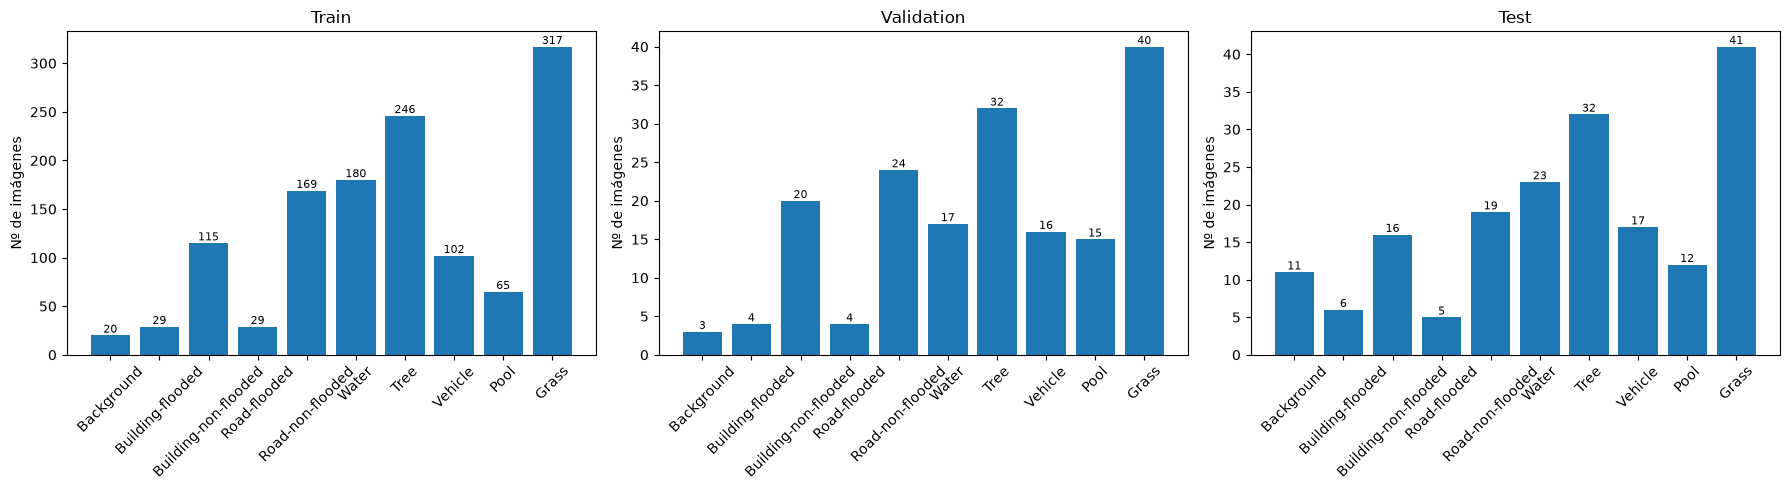

In [7]:
def plot_all_in_one_row(train_dist, val_dist, test_dist):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (titulo, dist) in zip(axes, [("Train", train_dist),
                                         ("Validation", val_dist),
                                         ("Test", test_dist)]):
        valores = [dist[i] for i in range(NUM_CLASSES)]
        barras = ax.bar(class_names, valores)
        ax.set_title(titulo)
        ax.set_ylabel("Nº de imágenes")
        ax.tick_params(axis="x", rotation=45)
        for b in barras:
            ax.text(b.get_x() + b.get_width()/2, b.get_height(),
                    str(int(b.get_height())), ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_all_in_one_row(train_img_dist, val_img_dist, test_img_dist)

---
# 3. Preprocesado: oversampling y augmentación

## Oversampling

El dataset está muy desbalanceado: `Grass` aparece en casi todas las imágenes
mientras que `Building-flooded` aparece en unas pocas decenas. Sin corregirlo, el
modelo aprende a ignorar las clases raras porque acertar siempre las frecuentes ya
minimiza la pérdida.

La estrategia: **repetir** en cada época las imágenes que contienen clases poco
representadas, hasta que todas las clases alcancen una frecuencia parecida.

## Dos pipelines de augmentación

Las copias repetidas reciben augmentación **más agresiva** (`aug_strong`:
deformaciones elásticas, distorsión de rejilla, rotaciones amplias) que los
originales (`aug_normal`). Así las repeticiones aportan variedad real en lugar de
ser duplicados idénticos, que es lo que provocaría sobreajuste.


In [9]:
import numpy as np
from collections import defaultdict, Counter
from PIL import Image
from tqdm import tqdm

def build_class_to_images(mask_paths):
    class_to_images = defaultdict(list)

    for idx, m in enumerate(tqdm(mask_paths, desc="Scanning masks")):
        mask = np.array(Image.open(m))
        unique_classes = np.unique(mask)

        for c in unique_classes:
            class_to_images[int(c)].append(idx)

    return class_to_images

def oversample_segmentation(train_imgs, train_masks, target_ratio=1.0):
    class_to_images = build_class_to_images(train_masks)

    class_counts = {c: len(idxs) for c, idxs in class_to_images.items()}
    max_count = max(class_counts.values())
    target_count = int(max_count * target_ratio)

    print("\nBefore oversampling:")
    for c in range(NUM_CLASSES):
        print(f"Class {c}: {class_counts.get(c, 0)}")

    oversampled_indices = []
    oversample_flags = []

    for i in range(len(train_imgs)):
        oversampled_indices.append(i)
        oversample_flags.append(False)

    # Oversample
    for c in range(NUM_CLASSES):
        indices = class_to_images.get(c, [])
        current_count = len(indices)

        if current_count == 0:
            continue

        if current_count < target_count:
            need = target_count - current_count
            extra = np.random.choice(indices, size=need, replace=True)

            for idx in extra:
                oversampled_indices.append(idx)
                oversample_flags.append(True)

    # Build dataset
    new_imgs = [train_imgs[i] for i in oversampled_indices]
    new_masks = [train_masks[i] for i in oversampled_indices]

    print(f"\nTotal images after oversampling: {len(new_imgs)}")
    print(f"Total flags: {len(oversample_flags)}")

    return new_imgs, new_masks, oversample_flags

In [10]:
oversampled_imgs, oversampled_masks, oversample_flags = oversample_segmentation(
    train_imgs, train_masks, target_ratio=1.0
)

new_dist = count_images_per_class(oversampled_masks, "Tras oversampling")
print("\nDistribución tras el oversampling:")
print({class_names[k]: v for k, v in new_dist.items()})

Scanning masks: 100%|██████████| 317/317 [00:00<00:00, 718.92it/s]



Before oversampling:
Class 0: 20
Class 1: 29
Class 2: 115
Class 3: 29
Class 4: 169
Class 5: 180
Class 6: 246
Class 7: 102
Class 8: 65
Class 9: 317

Total images after oversampling: 2215
Total flags: 2215



Distribución tras el oversampling:
{'Background': 364, 'Building-flooded': 831, 'Building-non-flooded': 1147, 'Road-flooded': 831, 'Road-non-flooded': 1069, 'Water': 1461, 'Tree': 1967, 'Vehicle': 1406, 'Pool': 1116, 'Grass': 2215}


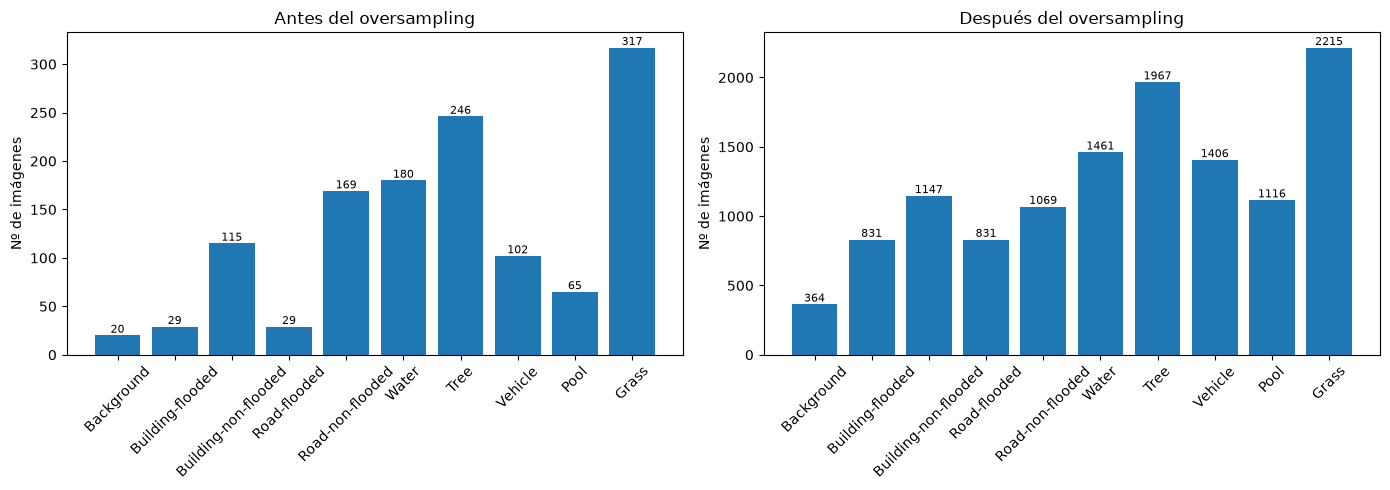

In [11]:
def plot_before_after(antes, despues):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (titulo, dist) in zip(axes, [("Antes del oversampling", antes),
                                         ("Después del oversampling", despues)]):
        valores = [dist[i] for i in range(NUM_CLASSES)]
        barras = ax.bar(class_names, valores)
        ax.set_title(titulo)
        ax.set_ylabel("Nº de imágenes")
        ax.tick_params(axis="x", rotation=45)
        for b in barras:
            ax.text(b.get_x() + b.get_width()/2, b.get_height(),
                    str(int(b.get_height())), ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_before_after(train_img_dist, new_dist)

### 3.1 Pipelines de augmentación

`A.Normalize` aplica la normalización de ImageNet (media y desviación por canal),
que es la que espera el backbone ConvNeXt preentrenado. `ToTensorV2` convierte a
tensor de PyTorch reordenando HWC → CHW.

Nota: la augmentación geométrica se aplica **a la vez** a imagen y máscara.
Albumentations lo gestiona automáticamente al pasarle `image=` y `mask=`.


In [12]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

aug_normal  = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(-0.1, 0.1),
        rotate=(-30, 30),
        p=0.5
    ),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    # A.GaussNoise(p=0.2),
    # A.CoarseDropout(
    #     num_holes_range=(1, 8),
    #     hole_height_range=(16, 64),
    #     hole_width_range=(16, 64),
    #     p=0.5
    # ),
    # A.HueSaturationValue(p=0.3),
    A.RandomGamma(p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], is_check_shapes=False)


aug_strong = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(translate_percent=0.1, scale=(0.8, 1.2), rotate=(-45, 45), p=0.7),
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120*0.05, p=0.5),
        A.GridDistortion(p=0.5),
    ], p=0.4),
    A.OneOf([
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.5),
        A.CLAHE(p=0.5),
    ], p=0.5),
    A.Resize(512, 512),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])



val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], is_check_shapes=False)

### 3.2 Datasets y DataLoaders

`BalancedFloodDataset` elige el pipeline según el flag de oversampling: las copias
extra reciben `aug_strong`, los originales `aug_normal`.

En Windows, `num_workers=0` es lo correcto: el arranque de procesos por *spawn*
hace que los workers salgan caros, y como las imágenes ya están cacheadas a 512×512
la carga es barata.


In [13]:
from torch.utils.data import Dataset

class BalancedFloodDataset(Dataset):
    def __init__(self, image_paths, mask_paths, oversample_flags):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.flags = oversample_flags

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
    
        if img is None or mask is None:
            raise RuntimeError(f"Lỗi đọc file {idx}")
    
        # 🔥 BƯỚC 1: FIX SHAPE GỐC (QUAN TRỌNG NHẤT)
        if img.shape[:2] != mask.shape[:2]:
            mask = cv2.resize(
                mask,
                (img.shape[1], img.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )
    
        # 🔥 BƯỚC 2: ĐƯA VỀ SIZE CHUNG
        img = cv2.resize(img, (512, 512))
        mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)
    
        # 🔥 BƯỚC 3: AUGMENTATION
        transform = aug_strong if self.flags[idx] else aug_normal
        augmented = transform(image=img, mask=mask)
    
        return augmented["image"], augmented["mask"].long()


class FloodDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        augmented = self.transform(image=img, mask=mask)

        return augmented["image"], augmented["mask"].long()

In [14]:
from torch.utils.data import DataLoader

train_dataset = BalancedFloodDataset(
    oversampled_imgs,
    oversampled_masks,
    oversample_flags
)

val_dataset = FloodDataset(val_imgs, val_masks, val_transform)
test_dataset = FloodDataset(test_imgs, test_masks, val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [15]:
images, masks = next(iter(train_loader))
print("Images shape:", images.shape)   # mong đợi: [4, 3, 512, 512]
print("Masks shape: ", masks.shape)    # mong đợi: [4, 512, 512]
print("Masks dtype: ", masks.dtype)     # mong đợi: torch.int64

Images shape: torch.Size([4, 3, 512, 512])
Masks shape:  torch.Size([4, 512, 512])
Masks dtype:  torch.int64


---
# 4. Arquitectura

Cuatro piezas, de dentro hacia fuera:

**`AttentionGate`** — filtra una skip connection usando el mapa del decoder como
consulta. Produce un mapa de pesos en [0,1] y multiplica la skip por él, de modo que
las zonas irrelevantes se atenúan antes de concatenarse.

**`ASPP`** *(Atrous Spatial Pyramid Pooling)* — aplica convoluciones con
dilataciones 1, 6, 12 y 18 en paralelo más un *global pooling*. Captura contexto a
varias escalas sin perder resolución.

**`TransformerBlock`** — self-attention multi-cabeza + MLP con conexiones
residuales. Sobre el cuello de botella (4×4 = 16 tokens) es barato y da campo
receptivo global.

**`ViT_UNet`** — el ensamblaje. Devuelve **tres** salidas: la principal y dos
auxiliares desde capas intermedias del decoder (*deep supervision*), que estabilizan
el gradiente en las capas profundas durante el entrenamiento.


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

# ========================= ATTENTION GATE & ASPP (giữ nguyên) =========================
class AttentionGate(nn.Module):
    def __init__(self, g_channels, x_channels, inter_channels):
        super().__init__()
        self.w_g = nn.Conv2d(g_channels, inter_channels, kernel_size=1)
        self.w_x = nn.Conv2d(x_channels, inter_channels, kernel_size=1)
        self.psi = nn.Conv2d(inter_channels, 1, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, g, x):
        g1 = self.w_g(g)
        x1 = self.w_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        psi = self.sigmoid(psi)
        return x * psi

class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=512, rates=[1, 6, 12, 18]):
        super().__init__()
        self.aspp1 = nn.Conv2d(in_channels, out_channels, 1)
        self.aspp2 = nn.Conv2d(in_channels, out_channels, 3, padding=rates[1], dilation=rates[1])
        self.aspp3 = nn.Conv2d(in_channels, out_channels, 3, padding=rates[2], dilation=rates[2])
        self.aspp4 = nn.Conv2d(in_channels, out_channels, 3, padding=rates[3], dilation=rates[3])
        
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1),
            nn.ReLU(inplace=True)
        )
        self.out_conv = nn.Conv2d(out_channels * 5, out_channels, 1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        f1, f2, f3, f4 = self.aspp1(x), self.aspp2(x), self.aspp3(x), self.aspp4(x)
        f5 = self.global_pool(x)
        f5 = F.interpolate(f5, size=x.shape[2:], mode='bilinear', align_corners=False)
        out = torch.cat([f1, f2, f3, f4, f5], dim=1)
        out = self.out_conv(out)
        out = self.bn(out)
        return self.relu(out)

# ========================= TransformerBlock =========================
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=8, mlp_ratio=4.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim)
        )
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

# ========================= DecoderBlock =========================
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        # self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        # Thay ConvTranspose bằng Upsample + Conv
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.att_gate = AttentionGate(out_channels, skip_channels, out_channels//2) if skip_channels > 0 else None
        
        total_in = out_channels + skip_channels if skip_channels > 0 else out_channels
        self.conv = nn.Sequential(
            nn.Conv2d(total_in, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
    
    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None and self.att_gate is not None:
            skip = F.interpolate(skip, size=x.shape[2:], mode='bilinear', align_corners=False)
            skip = self.att_gate(x, skip)
        if skip is not None:
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)

# ========================= HybridEncoder (ResNet50 + depth=12) =========================
class HybridEncoder(nn.Module):
    def __init__(self, img_size=512, patch_size=4, dim=512, depth=12, backbone_name='convnext_tiny'):
        """
        Hybrid Encoder với CNN backbone + Patch Embedding + Transformer
        - patch_size: kích thước patch (nên dùng 4 hoặc 2 để có đủ tokens)
        - backbone_name: 'resnet50', 'convnext_tiny', 'convnext_small',...
        """
        super().__init__()
        
        self.backbone_name = backbone_name
        self.backbone = timm.create_model(backbone_name, pretrained=True, features_only=True)
        
        # Xác định channel cho patch_embed và skip connections
        if 'resnet50' in backbone_name:
            self.patch_in_ch = 1024
            self.skip_channels = [64, 256, 512, 1024]   # level 0,1,2,3
        elif 'convnext_tiny' in backbone_name or 'convnext_small' in backbone_name:
            self.patch_in_ch = 768
            self.skip_channels = [96, 192, 384, 768]
        elif 'convnext_base' in backbone_name:
            self.patch_in_ch = 1024
            self.skip_channels = [128, 256, 512, 1024]
        else:
            raise ValueError(f"Unsupported backbone: {backbone_name}. Please add config.")
        
        # Patch embedding
        self.patch_embed = nn.Conv2d(self.patch_in_ch, dim, kernel_size=patch_size, stride=patch_size)
        
        # Positional embedding: tạo max size trước (an toàn, tránh dynamic trong forward)
        # Max giả định: patch_size=2 trên 16x16 → 64 tokens
        max_patches = (32 // 2) ** 2  # 256 cho an toàn
        self.pos_embedding = nn.Parameter(torch.randn(1, max_patches, dim))
        
        # Transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock(dim) for _ in range(depth)])

    def forward(self, x):
        features = self.backbone(x)  # list of feature maps
        
        # Lấy skip connections (level 0→3: high-res → low-res)
        x1, x2, x3, x4 = features[0], features[1], features[2], features[3]
        
        # Patch embedding từ level 3 (x4)
        patch_feat = self.patch_embed(x4)
        B, C, h, w = patch_feat.shape
        
        # Số patch thực tế
        num_patches = h * w
        
        # Slice pos_embedding theo số patch thực tế
        pos = self.pos_embedding[:, :num_patches, :]
        
        # Flatten & add pos
        tokens = patch_feat.flatten(2).transpose(1, 2)  # B, num_patches, dim
        tokens = tokens + pos
        
        # Transformer blocks
        for blk in self.blocks:
            tokens = blk(tokens)
        
        return tokens, x1, x2, x3, x4, h, w

# ========================= ViT-UNet (đã fix Deep Supervision) =========================
class ViT_UNet(nn.Module):
    def __init__(self, num_classes=10, dim=512, backbone_name='convnext_tiny'):
        super().__init__()
        self.encoder = HybridEncoder(img_size=512, patch_size=4, dim=dim, depth=12, backbone_name=backbone_name)
        
        # Lấy skip channels từ encoder (đã fix)
        skip_ch = self.encoder.skip_channels
        
        self.aspp = ASPP(dim, dim)
        
        self.dec1 = DecoderBlock(dim,   skip_ch[3], 256)   # skip x4 (lowest res)
        self.dec2 = DecoderBlock(256,   skip_ch[2], 128)   # skip x3
        self.dec3 = DecoderBlock(128,   skip_ch[1],  64)   # skip x2
        self.dec4 = DecoderBlock(64,    skip_ch[0],  32)   # skip x1 (highest res)
        self.dec5 = DecoderBlock(32,           0,   32)
        
        self.head = nn.Conv2d(32, num_classes, 1)
        
        self.aux_head2 = nn.Conv2d(128, num_classes, 1)
        self.aux_head3 = nn.Conv2d(64,  num_classes, 1)

    def forward(self, x):
        tokens, x1, x2, x3, x4, H, W = self.encoder(x)
        B, N, C = tokens.shape
        feat = tokens.transpose(1, 2).reshape(B, C, H, W)
        
        feat = self.aspp(feat)
        
        feat1 = self.dec1(feat, x4)
        feat2 = self.dec2(feat1, x3)
        feat3 = self.dec3(feat2, x2)
        feat4 = self.dec4(feat3, x1)
        feat5 = self.dec5(feat4, None)
        
        main_out = self.head(feat5)
        main_out = F.interpolate(main_out, size=(512, 512), mode='bilinear', align_corners=False)
        
        aux2 = self.aux_head2(feat2)
        aux2 = F.interpolate(aux2, size=(512, 512), mode='bilinear', align_corners=False)
        
        aux3 = self.aux_head3(feat3)
        aux3 = F.interpolate(aux3, size=(512, 512), mode='bilinear', align_corners=False)
        
        return main_out, aux2, aux3

In [18]:
if __name__ == "__main__":
    # Dùng ConvNeXt-Tiny
    model = ViT_UNet(num_classes=10, dim=512, backbone_name='convnext_tiny')
    x = torch.randn(2, 3, 512, 512)
    main, aux2, aux3 = model(x)
    print("Main output shape :", main.shape)
    print("Aux2 shape       :", aux2.shape)
    print("Aux3 shape       :", aux3.shape)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {total_params:,}")

Main output shape : torch.Size([2, 10, 512, 512])
Aux2 shape       : torch.Size([2, 10, 512, 512])
Aux3 shape       : torch.Size([2, 10, 512, 512])
Trainable parameters: 86,680,082


---
# 5. Entrenamiento


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = ViT_UNet(num_classes=10, dim=512, backbone_name='convnext_tiny').to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Device: cuda
Trainable parameters: 86,680,082


### 5.1 Lovász-Softmax

Dice e IoU no son diferenciables (dependen de un `argmax`). La pérdida
Lovász-Softmax es una extensión convexa del IoU que **sí** lo es, así que optimiza
directamente la métrica que interesa en vez de un sustituto.


In [20]:
def lovasz_grad(gt_sorted):
    """
    Computes gradient of the Lovász-Softmax loss w.r.t sorted errors
    See Alg. 1 in paper
    """
    p = len(gt_sorted)
    gts = gt_sorted.sum().float()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1. - intersection / union
    if p > 1:  # cover 1-pixel case
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

def lovasz_softmax_flat(probas, labels, classes='present'):
    """
    Multi-class Lovász-Softmax loss
    probas: [B*H*W, C]
    labels: [B*H*W]
    classes: 'all' for all, 'present' for classes present in labels
    """
    if probas.numel() == 0:
        # only void pixels, the gradients are 0
        return probas * 0.
    C = probas.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes in ['all', 'present'] else classes
    for c in class_to_sum:
        fg = (labels == c).float()  # foreground for class c
        if (classes == 'present' and fg.sum() == 0):
            continue
        if C == 1:
            if len(classes) > 1:
                raise ValueError('Sigmoid output possible only with 1 class')
            class_pred = probas[:, 0]
        else:
            class_pred = probas[:, c]
        errors = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        perm = perm.data
        fg_sorted = fg[perm]
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))
    return mean(losses)

def mean(l, ignore_nan=False, empty=0):
    """
    nanmean compatible with generators.
    """
    l = iter(l)
    if ignore_nan:
        l = ifilterfalse(isnan, l)
    try:
        n = 1
        acc = next(l)
    except StopIteration:
        if empty == 'raise':
            raise ValueError('Empty mean')
        return empty
    for n, v in enumerate(l, 2):
        acc += v
    if n == 0:
        return acc
    return acc / n

def isnan(x):
    return x != x

def ifilterfalse(predicate, iterable):
    for x in iterable:
        if not predicate(x):
            yield x

### 5.2 Pesos por clase

Los pesos se calculan con `1 / log(1.02 + n)`, que penaliza el desbalance de forma
más suave que el inverso de la frecuencia (`1/n`), donde una clase con 29 imágenes
recibiría un peso 12 veces mayor que una con 368 y desestabilizaría el entrenamiento.

> Corregido respecto al original: allí los conteos estaban **escritos a mano** y
> correspondían a otro conjunto de entrenamiento. Aquí se cuentan sobre el split
> real, que es lo único coherente.


In [21]:
counts = np.array([train_img_dist[i] for i in range(NUM_CLASSES)], dtype=np.int64)
print("Imágenes por clase (train):", counts.tolist())

# np.maximum evita un peso desorbitado si alguna clase no aparece en el split.
safe = np.maximum(counts, 1)
class_weights = 1 / np.log(1.02 + safe)
class_weights = class_weights / class_weights.sum() * len(class_weights)

for n, c, w in zip(class_names, counts, class_weights):
    print(f"  {n:<22} n={c:<4} peso={w:.3f}")

Imágenes por clase (train): [20, 29, 115, 29, 169, 180, 246, 102, 65, 317]
  Background             n=20   peso=1.413
  Building-flooded       n=29   peso=1.265
  Building-non-flooded   n=115  peso=0.905
  Road-flooded           n=29   peso=1.265
  Road-non-flooded       n=169  peso=0.838
  Water                  n=180  peso=0.828
  Tree                   n=246  peso=0.781
  Vehicle                n=102  peso=0.929
  Pool                   n=65   peso=1.027
  Grass                  n=317  peso=0.747


### 5.3 Función de pérdida combinada

`AdvancedLoss` suma cuatro términos sobre la salida principal (Dice + Lovász al
50 %) más las dos auxiliares con pesos 0.1 y 0.05. La idea es que Dice aporte
estabilidad y Lovász empuje directamente el IoU.


In [22]:
# ========================= FOCAL LOSS =========================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, pred, target):
        ce_loss = F.cross_entropy(
            pred,
            target,
            weight=self.weight,
            reduction='none'
        )
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# ========================= DICE LOSS (giữ nguyên của bạn) =========================
class DiceLoss(nn.Module):
    def __init__(self, num_classes=10, ignore_index=0):
        super().__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index

    def forward(self, pred, target, smooth=1e-6):
        pred = torch.softmax(pred, dim=1)
        target_onehot = nn.functional.one_hot(target, self.num_classes).permute(0, 3, 1, 2).float()
        intersection = (pred * target_onehot).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target_onehot.sum(dim=(2, 3))
        dice = (2 * intersection + smooth) / (union + smooth + 1e-8)
        # dice = dice[:, 1:]  # ignore background
        return 1 - dice.mean()

class AdvancedLoss(nn.Module):
    def __init__(self, num_classes=10, class_weights=None):
        super().__init__()

        if class_weights is not None:
            class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = DiceLoss(num_classes=num_classes)
        self.focal = FocalLoss(alpha=0.75, gamma=3.0, weight=class_weights)

    def forward(self, main_out, aux2, aux3, target):
        # Main loss
        main_ce   = self.ce(main_out, target)
        main_dice = self.dice(main_out, target)
        main_focal = self.focal(main_out, target)

        # Lovasz
        probas = F.softmax(main_out, dim=1)
        probas_flat = probas.permute(0,2,3,1).reshape(-1, probas.size(1))
        labels_flat = target.reshape(-1)

        main_lovasz = lovasz_softmax_flat(probas_flat, labels_flat, classes='present')

        # 👉 Loss chính (bạn đang dùng)
        loss_main = 0.5 * main_dice + 0.5 * main_lovasz

        # Aux loss
        aux2_loss = 0.1 * (self.ce(aux2, target) + self.dice(aux2, target))
        aux3_loss = 0.05 * (self.ce(aux3, target) + self.dice(aux3, target))

        return loss_main + aux2_loss + aux3_loss

### 5.4 Optimizador, scheduler y precisión mixta

**AMP** (*Automatic Mixed Precision*) ejecuta las operaciones en float16 donde es
seguro, casi duplicando la velocidad y reduciendo la VRAM. El `GradScaler` multiplica
la pérdida por un factor grande antes del `backward()` para que los gradientes
pequeños no se vuelvan cero en float16.

> Corregido respecto al original: `torch.cuda.amp.GradScaler()` está deprecado en
> favor de `torch.amp.GradScaler('cuda')`.


In [23]:
dice_loss = DiceLoss(num_classes=10)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)  # ↓ lr + AdamW

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

# Mixed precision
scaler = torch.amp.GradScaler('cuda')   # API actual

### 5.5 Métricas

In [24]:
def dice_score(pred, target, num_classes=10, smooth=1e-6):

    pred = torch.argmax(pred, dim=1)

    dice = 0

    for cls in range(num_classes):

        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()

        intersection = (pred_cls * target_cls).sum()

        dice_cls = (2 * intersection + smooth) / (
            pred_cls.sum() + target_cls.sum() + smooth
        )

        dice += dice_cls

    return dice / num_classes


def iou_score(pred, target, num_classes=10, smooth=1e-6):

    pred = torch.argmax(pred, dim=1)

    iou = 0

    for cls in range(num_classes):

        pred_cls = (pred == cls)
        target_cls = (target == cls)

        intersection = (pred_cls & target_cls).float().sum()
        union = (pred_cls | target_cls).float().sum()

        iou_cls = (intersection + smooth) / (union + smooth)

        iou += iou_cls

    return iou / num_classes


def pixel_accuracy(pred, target):

    pred = torch.argmax(pred, dim=1)

    correct = (pred == target).float().sum()
    total = torch.numel(target)

    return correct / total

### 5.6 Early stopping

Guarda el modelo cada vez que la pérdida de validación mejora y detiene el
entrenamiento si no mejora en `patience` épocas.


In [27]:
# =========================
# Early Stopping Class (bạn cung cấp)
# =========================
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0.0, path='checkpoint.pt', trace_func=print):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func

    def __call__(self, val_loss, model):
        score = -val_loss  # Vì loss càng nhỏ càng tốt → score càng lớn càng tốt

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [28]:
early_stopping = EarlyStopping(
    patience=50,              # chờ 10 epoch không cải thiện val loss
    verbose=True,
    delta=0.0001,
    path='best_model_loss.pth'  # lưu model tốt nhất theo val loss
)

In [29]:
def compute_per_class_stats(preds, targets, num_classes=10):
    preds = preds.argmax(dim=1)

    stats = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        intersection = (pred_cls & target_cls).sum().item()
        pred_sum = pred_cls.sum().item()
        target_sum = target_cls.sum().item()

        stats.append((intersection, pred_sum, target_sum))

    return stats

### 5.7 Bucles de entrenamiento y validación

**TTA** (*Test Time Augmentation*): en validación y test se predice sobre la imagen
original y sus tres volteos, se deshace el volteo de cada predicción y se promedian
las probabilidades. Cuesta 4 pasadas pero suele dar entre 1 y 2 puntos de IoU gratis.

> Corregido respecto al original: faltaba `scaler.unscale_(optimizer)` antes del
> `clip_grad_norm_`. Con AMP los gradientes están multiplicados por el factor de
> escala (típicamente 2^16), así que recortar a `max_norm=0.5` sobre gradientes
> escalados no recortaba nada: la protección contra gradientes explosivos era
> decorativa.


In [30]:
criterion = AdvancedLoss(num_classes=10, class_weights=class_weights).to(device)

def train_one_epoch(model, loader):
    model.train()
    total_loss = total_dice = total_iou = total_acc = 0.0
    n = 0
    loop = tqdm(loader, desc="Training")
    
    for images, masks in loop:
        images = images.to(device)
        masks  = masks.long().to(device)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast(device_type='cuda'):
            outputs, aux2, aux3 = model(images)
            loss = criterion(outputs, aux2, aux3, masks)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)   # imprescindible antes de recortar, ver nota arriba
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            dice = dice_score(outputs, masks)
            iou  = iou_score(outputs, masks)
            acc  = pixel_accuracy(outputs, masks)

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_dice += dice.item() * bs
        total_iou  += iou.item()  * bs
        total_acc  += acc.item()  * bs
        n += bs

        loop.set_postfix(loss=loss.item(), dice=dice.item(), iou=iou.item(), acc=acc.item())
    
    avg_loss = total_loss / n
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")
    return avg_loss, total_dice/n, total_iou/n, total_acc/n


# ========================= Cách 2: TTA (Test Time Augmentation) =========================
def tta_predict(model, images):
    """TTA đơn giản: gốc + flip ngang + flip dọc + flip cả 2"""
    preds = []
    with torch.no_grad():
        # 1. Original
        main, _, _ = model(images)
        preds.append(main)
        
        # 2. Flip ngang
        flip_h = torch.flip(images, dims=[3])
        main_h, _, _ = model(flip_h)
        preds.append(torch.flip(main_h, dims=[3]))
        
        # 3. Flip dọc
        flip_v = torch.flip(images, dims=[2])
        main_v, _, _ = model(flip_v)
        preds.append(torch.flip(main_v, dims=[2]))
        
        # 4. Flip cả ngang và dọc
        flip_hv = torch.flip(images, dims=[2, 3])
        main_hv, _, _ = model(flip_hv)
        preds.append(torch.flip(main_hv, dims=[2, 3]))
    
    # Trung bình xác suất
    preds = [torch.softmax(p, dim=1) for p in preds]
    return torch.mean(torch.stack(preds), dim=0)

def val_loss_fn(pred, target):
    dice = criterion.dice(pred, target)
    ce   = criterion.ce(pred, target)
    return 0.5 * ce + 0.5 * dice


def validate(model, loader):
    model.eval()

    total_loss = total_dice = total_iou = total_acc = 0.0
    n = 0

    # 🔥 accumulate stats
    total_stats = [ [0,0,0] for _ in range(10) ]

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation"):
            images = images.to(device)
            masks  = masks.long().to(device)

            outputs = tta_predict(model, images)

            loss = val_loss_fn(outputs, masks)

            dice = dice_score(outputs, masks)
            iou  = iou_score(outputs, masks)
            acc  = pixel_accuracy(outputs, masks)

            # 🔥 dùng stats chuẩn
            stats = compute_per_class_stats(outputs, masks)

            for i in range(10):
                total_stats[i][0] += stats[i][0]  # intersection
                total_stats[i][1] += stats[i][1]  # pred
                total_stats[i][2] += stats[i][2]  # target

            bs = images.size(0)
            total_loss += loss.item() * bs
            total_dice += dice.item() * bs
            total_iou  += iou.item()  * bs
            total_acc  += acc.item()  * bs
            n += bs

    # 🔥 tính final per-class
    dice_cls = []
    iou_cls  = []

    for inter, pred_sum, target_sum in total_stats:
        dice = (2*inter + 1e-6) / (pred_sum + target_sum + 1e-6)
        iou  = (inter + 1e-6) / (pred_sum + target_sum - inter + 1e-6)

        dice_cls.append(dice)
        iou_cls.append(iou)

    return total_loss/n, total_dice/n, total_iou/n, total_acc/n, dice_cls, iou_cls

In [31]:
def test_model(model, loader):
    model.eval()

    total_dice = 0.0
    total_iou = 0.0
    total_acc = 0.0
    n = 0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Testing"):
            images = images.to(device)
            masks = masks.long().to(device)

            # 🔥 dùng TTA giống validation
            outputs = tta_predict(model, images)

            dice = dice_score(outputs, masks)
            iou  = iou_score(outputs, masks)
            acc  = pixel_accuracy(outputs, masks)

            bs = images.size(0)
            total_dice += dice.item() * bs
            total_iou  += iou.item()  * bs
            total_acc  += acc.item()  * bs
            n += bs

    print("\n===== TEST RESULT =====")
    print(f"Dice: {total_dice/n:.4f}")
    print(f"IoU : {total_iou/n:.4f}")
    print(f"Acc : {total_acc/n:.4f}")

    return total_dice/n, total_iou/n, total_acc/n

### 5.8 El bucle principal

Con ~2.500 imágenes por época tras el oversampling y `batch_size=4`, son unas 640
iteraciones por época. En una RTX 4060 Laptop, cuenta del orden de varios minutos
por época más la validación con TTA.

> Corregido respecto al original: `scheduler.step(val_loss)`.
> `CosineAnnealingWarmRestarts.step(x)` interpreta `x` como el **número de época**,
> no como una métrica (eso es `ReduceLROnPlateau`). Pasarle la pérdida hacía saltar
> el learning rate de forma errática durante todo el entrenamiento.

Si aparece `CUDA out of memory`, baja `batch_size` a 2 en la sección 3.2.


In [32]:
num_epochs = 30

best_dice = 0.0
best_iou = 0.0
best_acc = 0.0

train_loss_history, val_loss_history = [], []
train_dice_history, val_dice_history = [], []
train_iou_history, val_iou_history = [], []
train_acc_history, val_acc_history = [], []

per_class_dice_history = []
per_class_iou_history  = []


for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    
    train_loss, train_dice, train_iou, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_dice, val_iou, val_acc, dice_cls, iou_cls = validate(model, val_loader)
    
    scheduler.step()   # sin argumento: ver nota arriba
    
    # Lưu lịch sử
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_dice_history.append(train_dice)
    val_dice_history.append(val_dice)
    train_iou_history.append(train_iou)
    val_iou_history.append(val_iou)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    per_class_dice_history.append(dice_cls)
    per_class_iou_history.append(iou_cls)
    
    print(f"Train → Acc: {train_acc:.4f} | Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | IoU: {train_iou:.4f}")
    print(f"Val   → Acc: {val_acc:.4f} | Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")
    
    # Lưu model tốt nhất theo Dice
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_vit_unet_dice.pth")
        print(f"→ Best model saved! (val Dice: {val_dice:.4f})")

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "best_model_iou.pth")
        print(f"→ Best model saved! (val IoU: {val_iou:.4f})")

    if val_acc > best_acc:
        best_acc = val_acc
    
    # Early stopping theo validation loss
    early_stopping(val_loss, model)
    
    if early_stopping.early_stop:
        print("\nEarly stopping triggered! Training dừng sớm.")
        break

print("\nTraining hoàn tất!")
print(f"Best validation Acc: {best_acc:.4f}")
print(f"Best validation Dice: {best_dice:.4f}")
print(f"Best validation IoU: {best_iou:.4f}")
print(f"Best validation loss (theo EarlyStopping): {early_stopping.val_loss_min:.6f}")


Epoch 1/30


Training: 100%|██████████| 554/554 [02:52<00:00,  3.21it/s, acc=0.859, dice=0.694, iou=0.622, loss=0.863]  


Current LR: 0.000030


Validation: 100%|██████████| 10/10 [00:04<00:00,  2.14it/s]


Train → Acc: 0.6635 | Loss: 1.0665 | Dice: 0.4426 | IoU: 0.3585
Val   → Acc: 0.8588 | Loss: 1.5074 | Dice: 0.5704 | IoU: 0.5042
→ Best model saved! (val Dice: 0.5704)
→ Best model saved! (val IoU: 0.5042)
Validation loss decreased (inf --> 1.507413).  Saving model ...

Epoch 2/30


...

Train → Acc: 0.9533 | Loss: 0.4330 | Dice: 0.8944 | IoU: 0.8365
Val   → Acc: 0.9275 | Loss: 1.2343 | Dice: 0.8123 | IoU: 0.7480
EarlyStopping counter: 4 out of 50

Epoch 30/30


Training: 100%|██████████| 554/554 [02:41<00:00,  3.43it/s, acc=0.928, dice=0.734, iou=0.681, loss=0.487]


Current LR: 0.000000


Validation: 100%|██████████| 10/10 [00:02<00:00,  3.38it/s]

Train → Acc: 0.9535 | Loss: 0.4330 | Dice: 0.8974 | IoU: 0.8400
Val   → Acc: 0.9271 | Loss: 1.2334 | Dice: 0.8216 | IoU: 0.7570
EarlyStopping counter: 5 out of 50

Training hoàn tất!
Best validation Acc: 0.9301
Best validation Dice: 0.8324
Best validation IoU: 0.7690
Best validation loss (theo EarlyStopping): 1.233493


---
# 6. Evaluación y visualización


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = class_mapping['Class Name'].tolist()

epochs = range(1, len(train_loss_history) + 1)

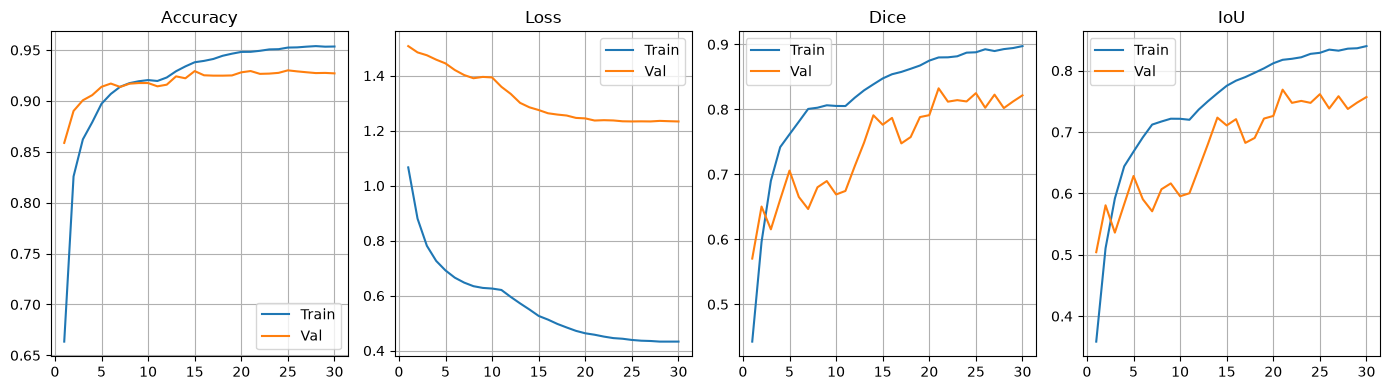

In [34]:
# ========================= 1. OVERALL METRICS =========================
plt.figure(figsize=(14,4))

plt.subplot(1,4,1)
plt.plot(epochs, train_acc_history, label="Train")
plt.plot(epochs, val_acc_history, label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.subplot(1,4,2)
plt.plot(epochs, train_loss_history, label="Train")
plt.plot(epochs, val_loss_history, label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,4,3)
plt.plot(epochs, train_dice_history, label="Train")
plt.plot(epochs, val_dice_history, label="Val")
plt.title("Dice")
plt.legend()
plt.grid()

plt.subplot(1,4,4)
plt.plot(epochs, train_iou_history, label="Train")
plt.plot(epochs, val_iou_history, label="Val")
plt.title("IoU")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

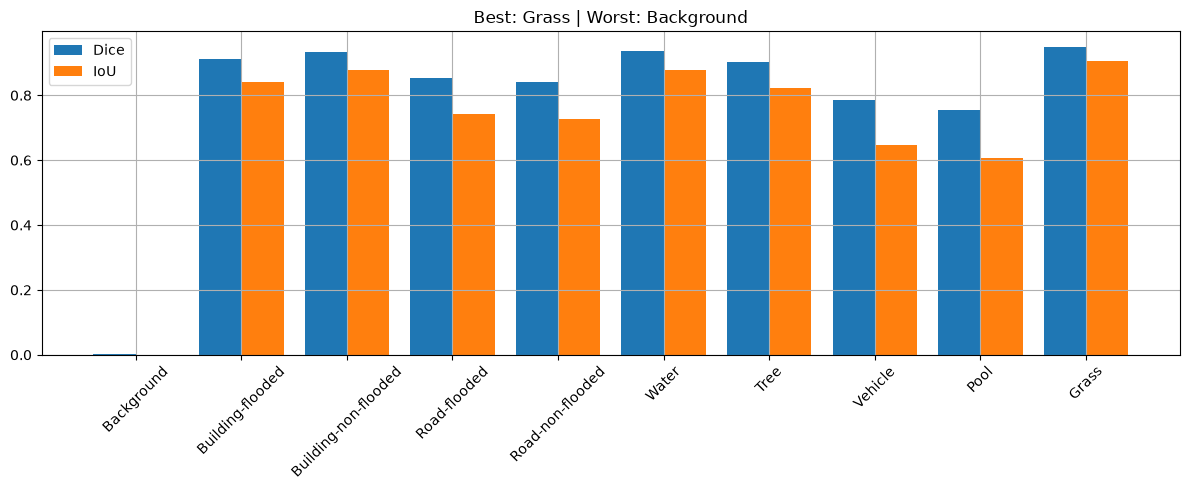

In [35]:
# ========================= 2. PER-CLASS BAR =========================
dice_cls = np.array(per_class_dice_history[-1])
iou_cls  = np.array(per_class_iou_history[-1])

x = np.arange(len(class_names))

worst_idx = np.argmin(dice_cls)
best_idx  = np.argmax(dice_cls)

plt.figure(figsize=(12,5))
plt.bar(x-0.2, dice_cls, width=0.4, label="Dice")
plt.bar(x+0.2, iou_cls,  width=0.4, label="IoU")

plt.xticks(x, class_names, rotation=45)
plt.title(f"Best: {class_names[best_idx]} | Worst: {class_names[worst_idx]}")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

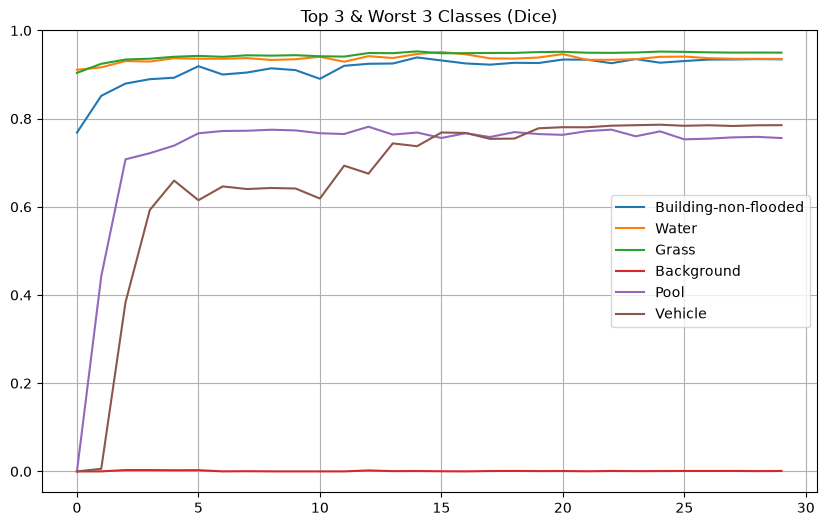

In [36]:
# ========================= 3. PER-CLASS OVER TIME =========================
per_class_dice_history_np = np.array(per_class_dice_history)

final_dice = per_class_dice_history_np[-1]

top_idx = np.argsort(final_dice)[-3:]
worst_idx = np.argsort(final_dice)[:3]

plt.figure(figsize=(10,6))

for i in list(top_idx) + list(worst_idx):
    plt.plot(per_class_dice_history_np[:, i], label=class_names[i])

plt.legend()
plt.title("Top 3 & Worst 3 Classes (Dice)")
plt.grid()
plt.show()

### 6.1 Predicciones de ejemplo

> Corregido respecto al original: las imágenes salen del DataLoader normalizadas
> (media 0, desviación 1), así que contienen valores negativos. Pasárselas a
> `imshow` directamente produce colores falseados; hay que deshacer la
> normalización antes.


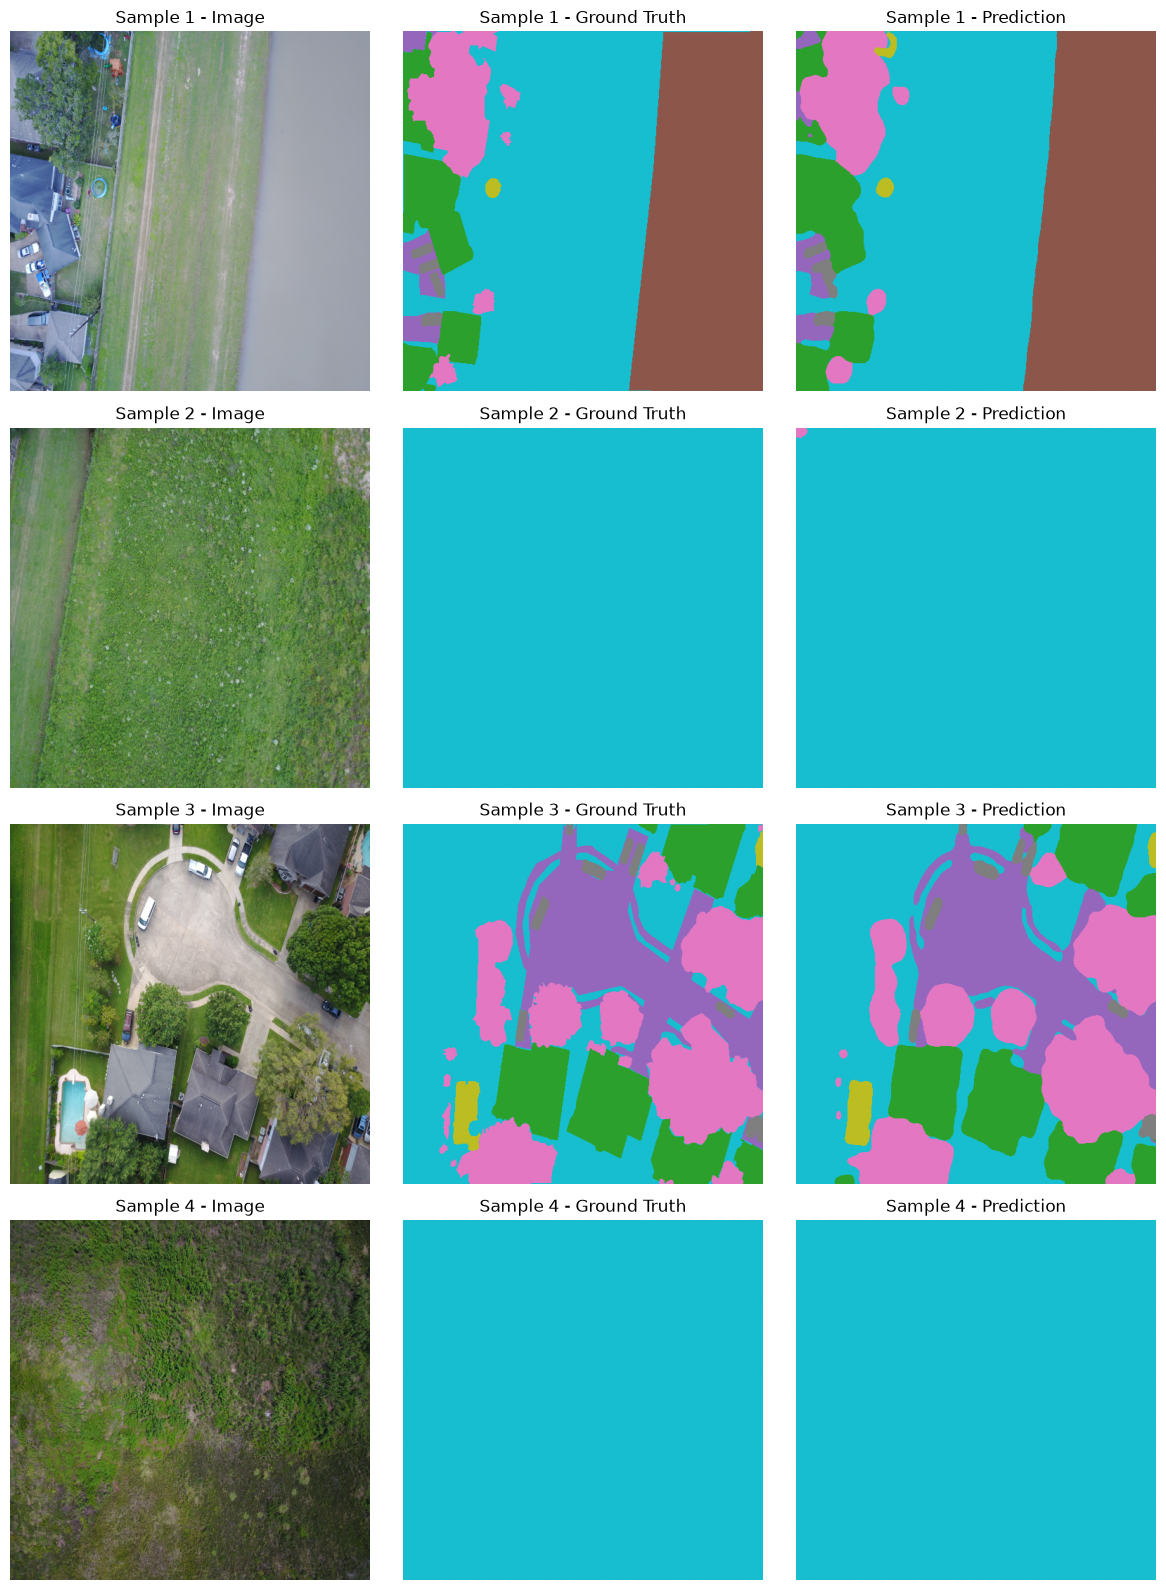

In [37]:
def visualize_samples(model, loader, num_samples=5):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(device)
    
    with torch.no_grad():
        outputs = tta_predict(model, images)
    preds = outputs.argmax(dim=1)

    num_samples = min(num_samples, images.size(0))

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    for i in range(num_samples):
        # Deshacer A.Normalize para que los colores sean los reales
        _mean = np.array([0.485, 0.456, 0.406])
        _std  = np.array([0.229, 0.224, 0.225])
        img  = images[i].cpu().permute(1,2,0).numpy() * _std + _mean
        img  = np.clip(img, 0, 1)
        mask = masks[i].cpu().numpy()
        pred = preds[i].cpu().numpy()

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Sample {i+1} - Image")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='tab10', vmin=0, vmax=9)
        axes[i, 1].set_title(f"Sample {i+1} - Ground Truth")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred, cmap='tab10', vmin=0, vmax=9)
        axes[i, 2].set_title(f"Sample {i+1} - Prediction")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples(model, val_loader, num_samples=5)

### 6.2 Matriz de confusión

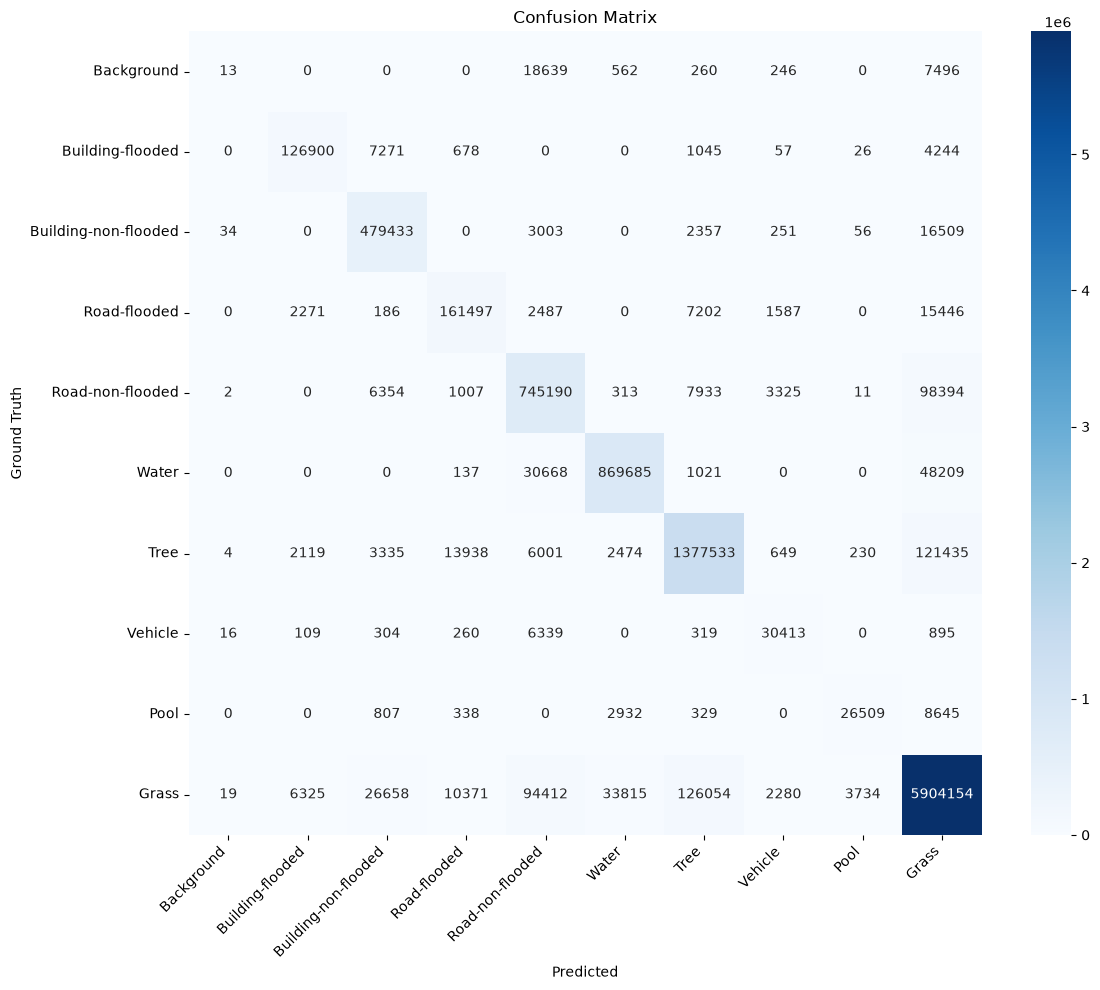

In [38]:
def plot_confusion(model, loader):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for i, (images, masks) in enumerate(loader):
            try:
                images = images.to(device)
                outputs = tta_predict(model, images)
                preds = outputs.argmax(dim=1)
                all_preds.append(preds.cpu().numpy().flatten())
                all_targets.append(masks.numpy().flatten())
            except Exception as e:
                print(f"❌ lỗi batch {i}: {e}")
                continue
    if len(all_preds) == 0:
        print("❌ Không có dữ liệu hợp lệ")
        return
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Blues', annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion(model, val_loader)

### 6.3 Resultados sobre el conjunto de test

In [39]:
test_dice, test_iou, test_acc = test_model(model, test_loader)

Testing: 100%|██████████| 11/11 [00:04<00:00,  2.31it/s]


===== TEST RESULT =====
Dice: 0.8086
IoU : 0.7448
Acc : 0.9248


In [40]:
def test_per_class(model, loader, num_classes=10):
    model.eval()

    dice_cls = np.zeros(num_classes)
    iou_cls  = np.zeros(num_classes)
    count = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = tta_predict(model, images)
            preds = outputs.argmax(dim=1)

            for c in range(num_classes):
                pred_c = (preds == c)
                mask_c = (masks == c)

                intersection = (pred_c & mask_c).sum().item()
                union = (pred_c | mask_c).sum().item()

                if union > 0:
                    dice_cls[c] += (2 * intersection) / (pred_c.sum().item() + mask_c.sum().item() + 1e-6)
                    iou_cls[c]  += intersection / (union + 1e-6)

            count += 1

    dice_cls /= count
    iou_cls  /= count

    return dice_cls, iou_cls



Background: Dice=0.0470, IoU=0.0317
Building-flooded: Dice=0.4198, IoU=0.3901
Building-non-flooded: Dice=0.6996, IoU=0.6320
Road-flooded: Dice=0.3816, IoU=0.3313
Road-non-flooded: Dice=0.7961, IoU=0.7138
Water: Dice=0.9424, IoU=0.8927
Tree: Dice=0.8167, IoU=0.7484
Vehicle: Dice=0.5882, IoU=0.4817
Pool: Dice=0.5316, IoU=0.4460
Grass: Dice=0.9387, IoU=0.8918


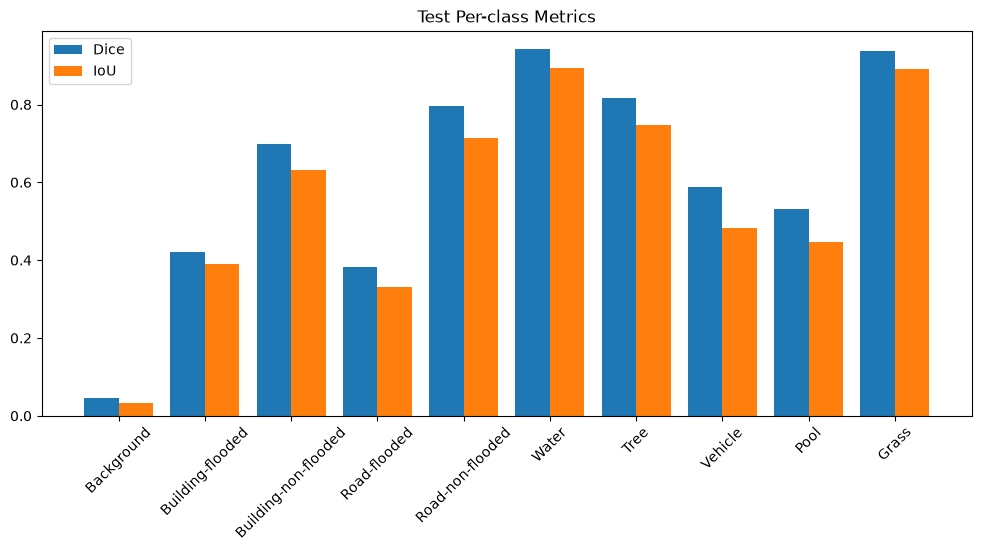

In [41]:
dice_cls, iou_cls = test_per_class(model, test_loader, num_classes=10)

for i, name in enumerate(class_names):
    print(f"{name}: Dice={dice_cls[i]:.4f}, IoU={iou_cls[i]:.4f}")

x = np.arange(len(class_names))

plt.figure(figsize=(12,5))
plt.bar(x-0.2, dice_cls, width=0.4, label="Dice")
plt.bar(x+0.2, iou_cls,  width=0.4, label="IoU")

plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.title("Test Per-class Metrics")
plt.show()

### 6.4 Recarga del mejor checkpoint y evaluación final

In [42]:
model.load_state_dict(torch.load("best_model_iou.pth"))

<All keys matched successfully>

In [43]:
test_dice, test_iou, test_acc = test_model(model, test_loader)
print(f"Final Test IoU: {test_iou:.4f}")


Testing: 100%|██████████| 11/11 [00:02<00:00,  3.74it/s]


===== TEST RESULT =====
Dice: 0.8035
IoU : 0.7398
Acc : 0.9237
Final Test IoU: 0.7398
